In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', None) 
pd.set_option('display.max_columns', None)  

In [3]:
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

In [4]:
train_data.head(5)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [5]:
test_data.head(5)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000
3,2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014
4,2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014


In [6]:
train_data.shape, test_data.shape

((10886, 12), (6493, 9))

## 1.Combining train and test datasets

In [7]:
test_data['casual'] = 0
test_data['registered'] = 0
test_data['count'] = 0

train_test_data = pd.concat([train_data,test_data], axis=0)

- Creating extra columns with all zero value in test dataset before merging

## 2. Data Exploration

In [8]:
train_test_data.head(10)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
5,2011-01-01 05:00:00,1,0,0,2,9.84,12.880,75,6.0032,0,1,1
6,2011-01-01 06:00:00,1,0,0,1,9.02,13.635,80,0.0000,2,0,2
7,2011-01-01 07:00:00,1,0,0,1,8.20,12.880,86,0.0000,1,2,3
8,2011-01-01 08:00:00,1,0,0,1,9.84,14.395,75,0.0000,1,7,8
9,2011-01-01 09:00:00,1,0,0,1,13.12,17.425,76,0.0000,8,6,14


In [9]:
train_test_data.shape

(17379, 12)

In [10]:
train_test_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17379 entries, 0 to 6492
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    17379 non-null  object 
 1   season      17379 non-null  int64  
 2   holiday     17379 non-null  int64  
 3   workingday  17379 non-null  int64  
 4   weather     17379 non-null  int64  
 5   temp        17379 non-null  float64
 6   atemp       17379 non-null  float64
 7   humidity    17379 non-null  int64  
 8   windspeed   17379 non-null  float64
 9   casual      17379 non-null  int64  
 10  registered  17379 non-null  int64  
 11  count       17379 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1.7+ MB


- No null values.
- All columns are numerical except datetime.

In [11]:
train_test_data.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,2.501640,0.028770,0.682721,1.425283,20.376474,23.788755,62.722884,12.736540,22.563726,97.436044,119.999770
std,1.106918,0.167165,0.465431,0.639357,7.894801,8.592511,19.292983,8.196795,43.210268,141.251913,170.711941
min,1.000000,0.000000,0.000000,1.000000,0.820000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,13.940000,16.665000,48.000000,7.001500,0.000000,0.000000,0.000000
50%,3.000000,0.000000,1.000000,1.000000,20.500000,24.240000,63.000000,12.998000,3.000000,23.000000,28.000000
75%,3.000000,0.000000,1.000000,2.000000,27.060000,31.060000,78.000000,16.997900,26.000000,155.000000,192.000000
max,4.000000,1.000000,1.000000,4.000000,41.000000,50.000000,100.000000,56.996900,367.000000,886.000000,977.000000


In [12]:
train_test_data.nunique()

datetime      17379
season            4
holiday           2
workingday        2
weather           4
temp             50
atemp            65
humidity         89
windspeed        30
casual          309
registered      731
count           823
dtype: int64

- We will treat season, holiday, workingday, weather are catagoical and others are continous.

## 3.Analyzing data 

### 3.1 Extracting Datetime

In [13]:
train_test_data['datetime'] = pd.to_datetime(train_test_data['datetime'])
train_test_data['year'] = train_test_data['datetime'].dt.year
train_test_data['month'] = train_test_data['datetime'].dt.month
train_test_data['date'] = train_test_data['datetime'].dt.day
train_test_data['day'] = train_test_data['datetime'].dt.day_of_week
train_test_data['hour'] = train_test_data['datetime'].dt.hour

- Column `date` has values from 1-31.
- For column `day` : Monday=0, Sunday=6.
- Column hour has values 0-23

#### Mapping with names for better understanding

In [14]:
train_test_data_mapped = train_test_data.copy()

weather_map = {
    1: 'Good',
    2: 'Normal',
    3: 'Bad',
    4: 'Very Bad'
}

season_map = {
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
}

day_map = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}

train_test_data_mapped["weather"] = train_test_data["weather"].map(weather_map)
train_test_data_mapped["season"] = train_test_data["season"].map(season_map)
train_test_data_mapped["day"] = train_test_data["day"].map(day_map)

- Creating another dataframe becouse we need the numerical values for various plots.

### 3.2 Checking frequency and range of various features (Univariate Analysis)

#### 3.2.1 Categorical features

In [15]:
categorical_data = ['season', 'holiday', 'workingday', 'weather', 'year', 'day']

continuous_data = [column for column in train_test_data.columns if column not in categorical_data]

continuous_data.remove('datetime')

categorical_data, continuous_data

(['season', 'holiday', 'workingday', 'weather', 'year', 'day'],
 ['temp',
  'atemp',
  'humidity',
  'windspeed',
  'casual',
  'registered',
  'count',
  'month',
  'date',
  'hour'])

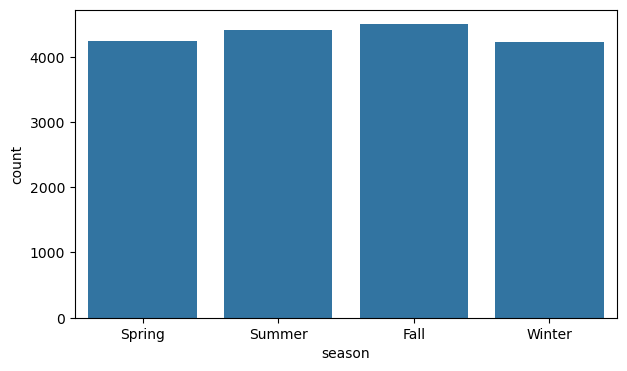

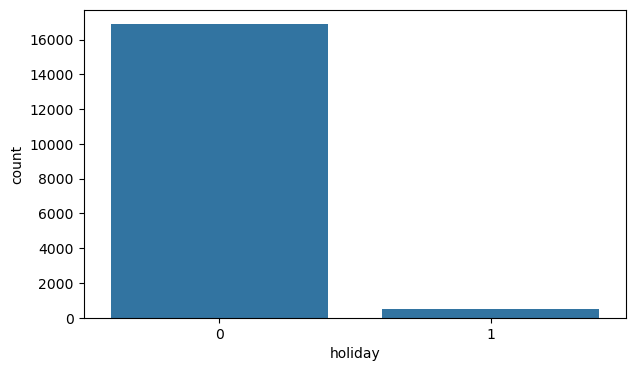

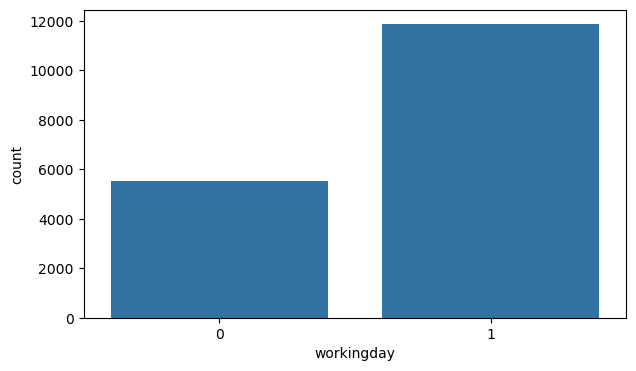

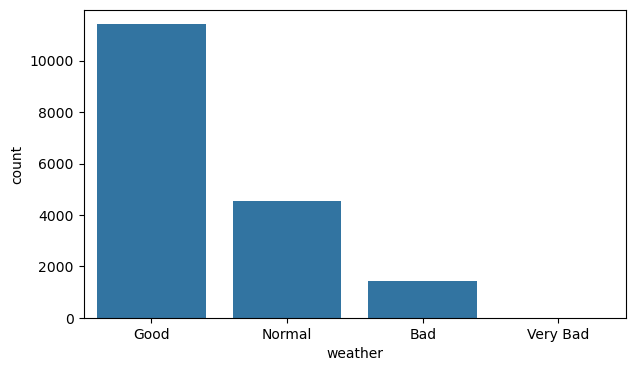

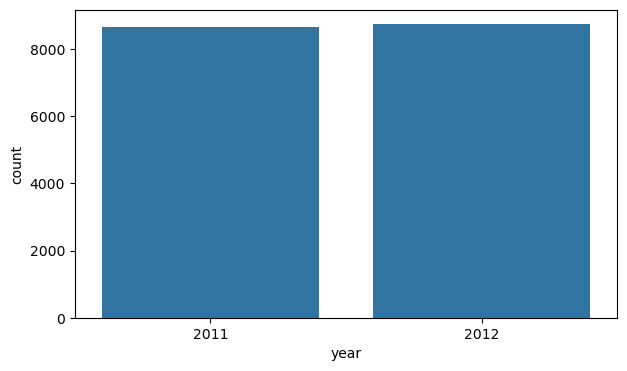

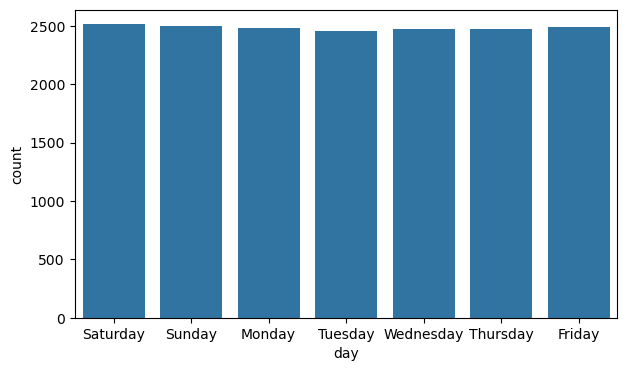

In [16]:
for feature in categorical_data:
    plt.figure(figsize=(7,4))
    sns.countplot(x=feature, data=train_test_data_mapped)
    plt.show()

- All seasons have nearly same count.
- We can create a column `offday` which is neither holiday nor workingday.
- `Good` weather is most frequent, then `Normal` weather, then `Bad` weather and rarely it is `Very Bad` weather 

#### 3.2.2 Continuous feature

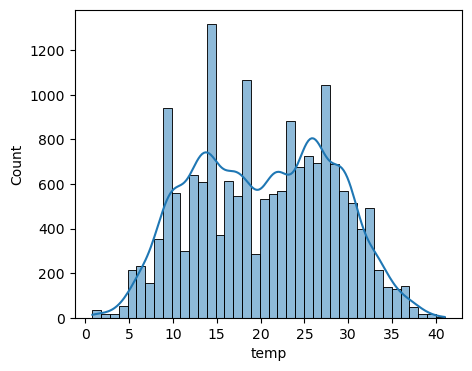

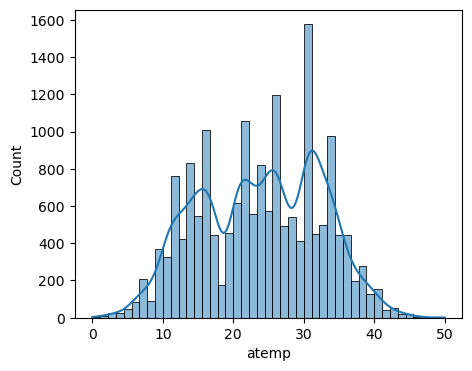

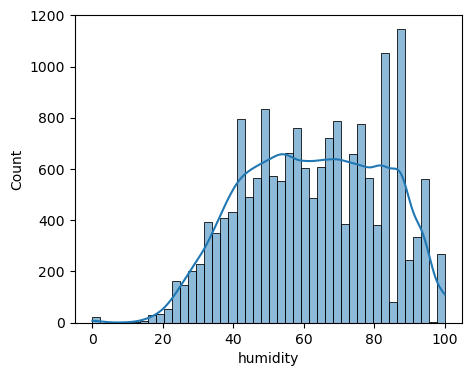

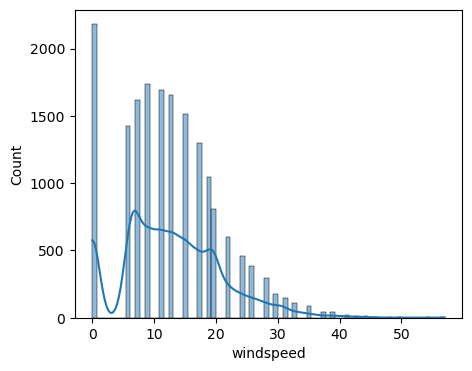

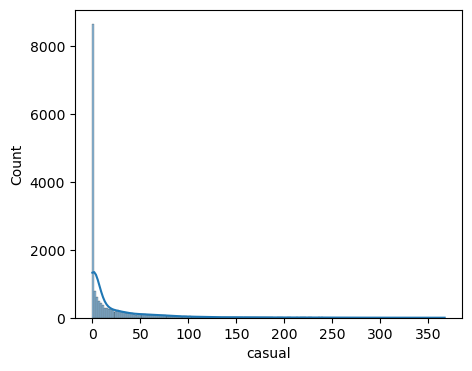

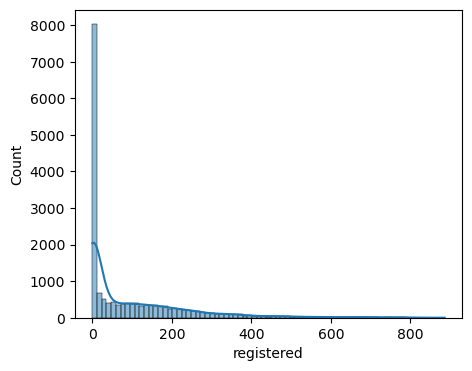

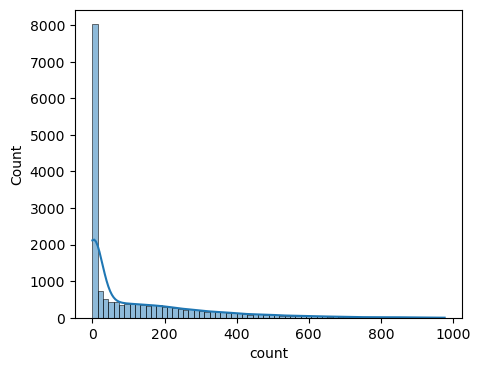

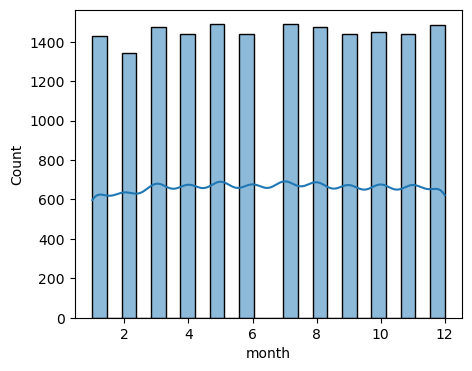

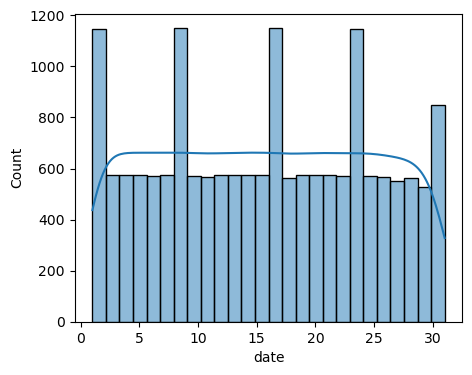

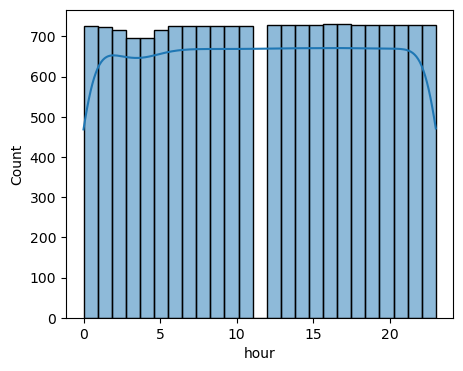

In [17]:
for feature in continuous_data:
    plt.figure(figsize=(5,4))
    sns.histplot(x=feature, data=train_test_data, kde=True)
    plt.show()

- We have a good idea about the range of values and distributions of this features from this graphs.

### 3.3 Finding relations with count (Bivariate Analysis - categorical and continuous)

In [18]:
train_test_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17379 entries, 0 to 6492
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    17379 non-null  datetime64[ns]
 1   season      17379 non-null  int64         
 2   holiday     17379 non-null  int64         
 3   workingday  17379 non-null  int64         
 4   weather     17379 non-null  int64         
 5   temp        17379 non-null  float64       
 6   atemp       17379 non-null  float64       
 7   humidity    17379 non-null  int64         
 8   windspeed   17379 non-null  float64       
 9   casual      17379 non-null  int64         
 10  registered  17379 non-null  int64         
 11  count       17379 non-null  int64         
 12  year        17379 non-null  int32         
 13  month       17379 non-null  int32         
 14  date        17379 non-null  int32         
 15  day         17379 non-null  int32         
 16  hour        17379 non-null  

In [19]:
train_test_data.drop(columns='datetime', inplace=True)

In [20]:
train_test_data.head(5)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,date,day,hour
0,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,5,0
1,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,5,1
2,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,5,2
3,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,1,5,3
4,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,1,5,4


In [21]:
year_map = {
    2011 : 0,
    2012 : 1
}
train_test_data['year'] = train_test_data['year'].map(year_map)

#### 3.3.2 Correlation

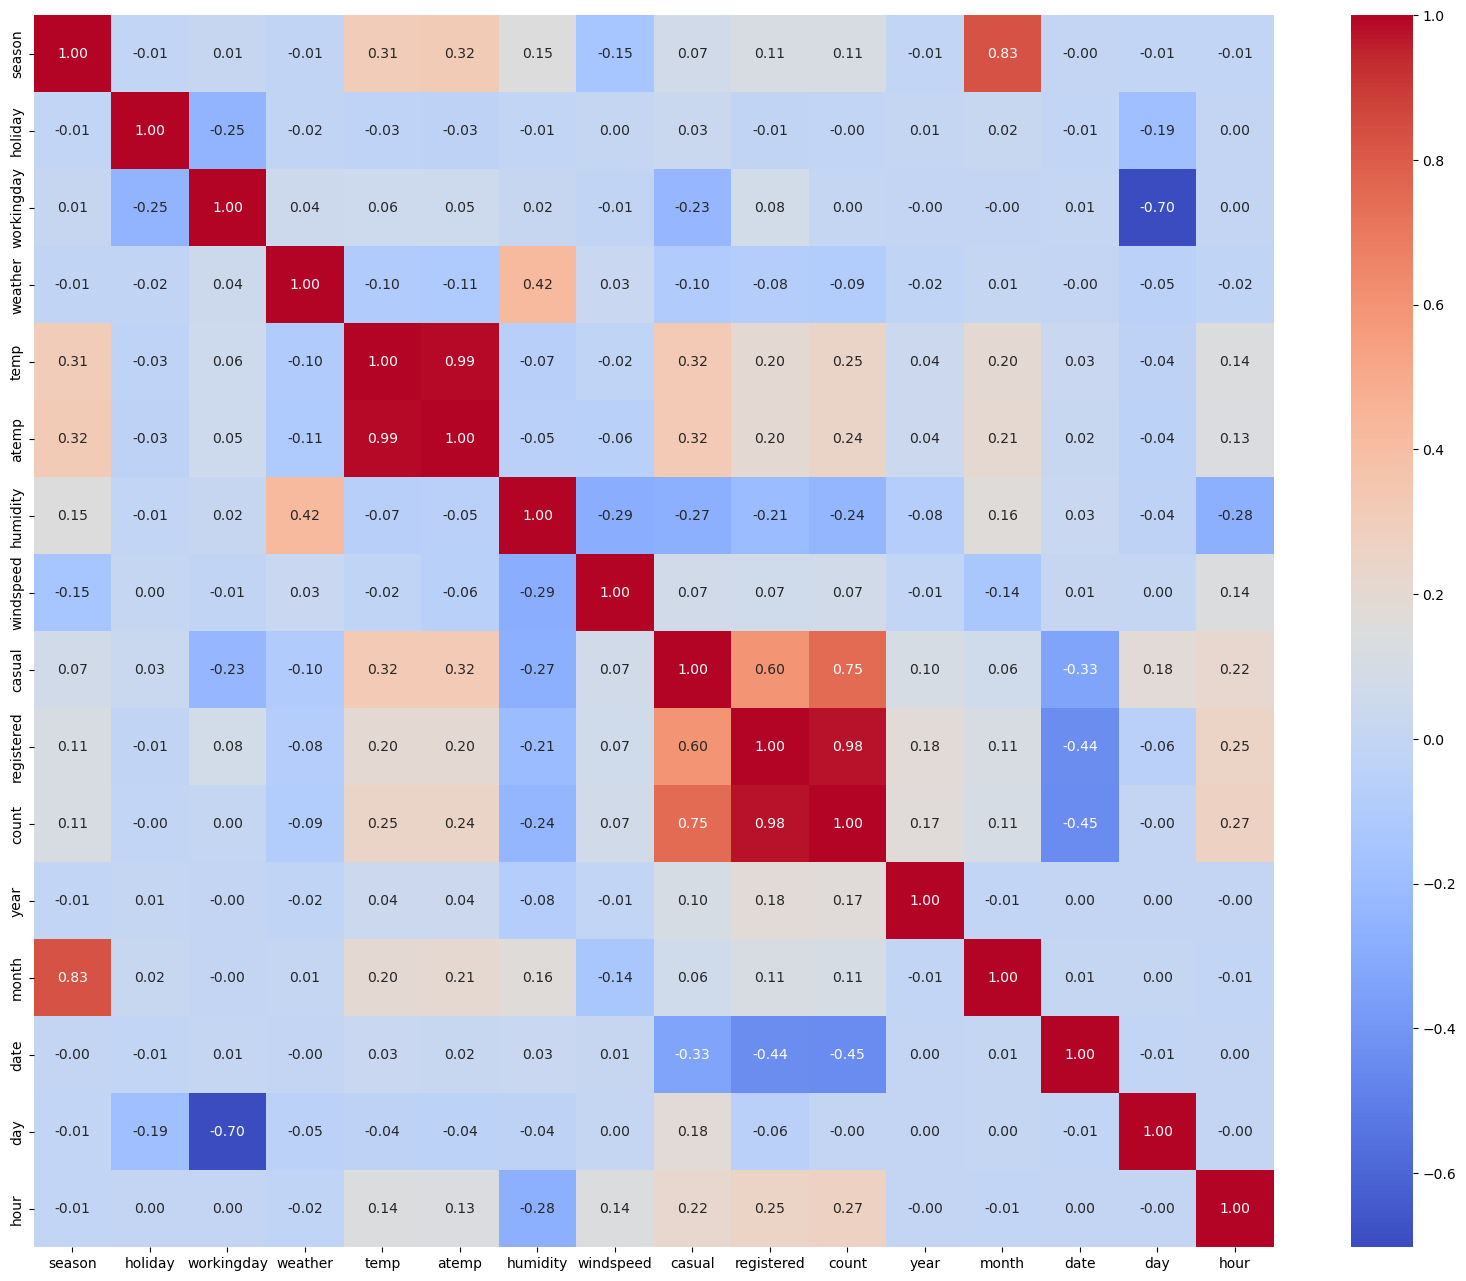

In [22]:
plt.figure(figsize=(20,16))
sns.heatmap(train_test_data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

### 3.3.3 Visualization

In [23]:
features = [column for column in train_test_data.columns]

In [24]:
for feature in features:
    print(f"{feature} -> {train_test_data[feature].nunique()}")

season -> 4
holiday -> 2
workingday -> 2
weather -> 4
temp -> 50
atemp -> 65
humidity -> 89
windspeed -> 30
casual -> 309
registered -> 731
count -> 823
year -> 2
month -> 12
date -> 31
day -> 7
hour -> 24


In [25]:
categorical_features = ['season', 'holiday', 'workingday', 'weather', 'year', 'day']
time_features = ['month', 'hour', 'date']
continuous_features = [column for column in train_test_data.columns if column not in categorical_features and column not in time_features]

#### Categorical features

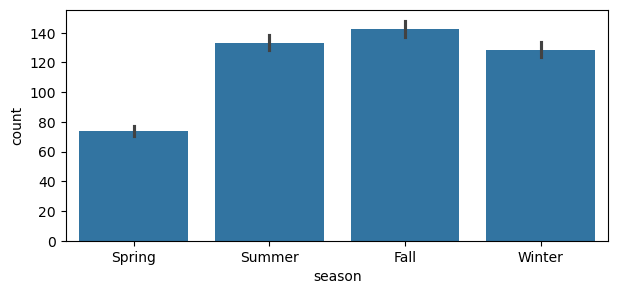

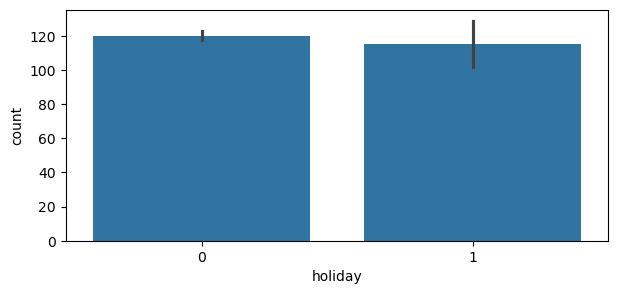

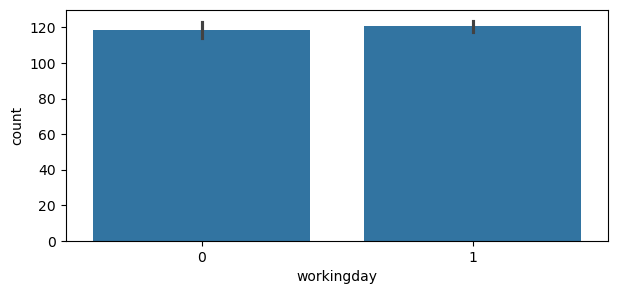

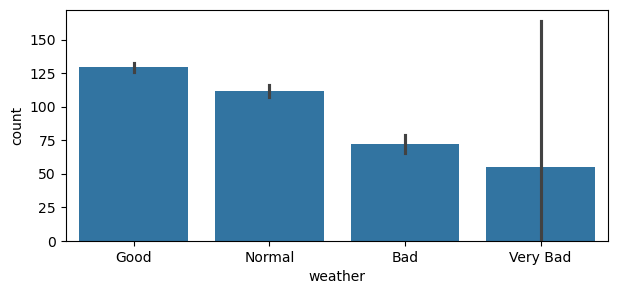

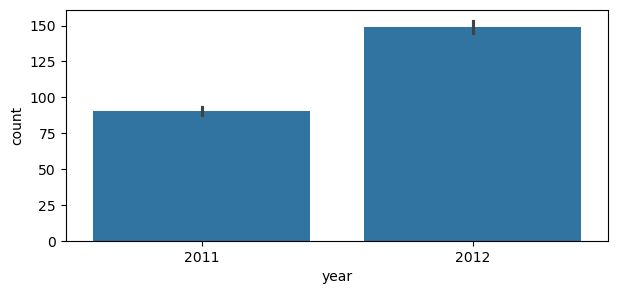

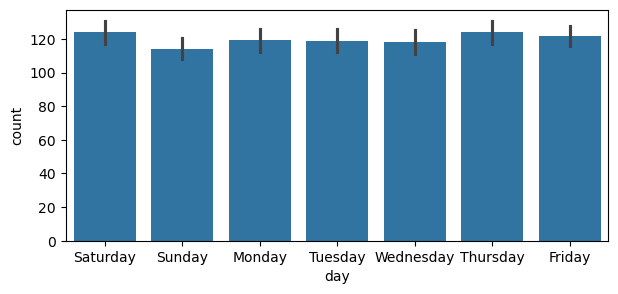

In [26]:
for feature in categorical_features:
    plt.figure(figsize=(7,3))
    sns.barplot(x=feature, y='count', data=train_test_data_mapped)
    plt.show()

- Seasonal Demand : Fall(3) > Summer(2) > Winter(4) > Spring(1). [In spring the demand is significantly low]
- In Holiday, Workingday, Off day Demand remains almost same.
- As the weather get worse the demand decreases. [There is high uncertainity for `Very Bad` weather]
- Yearly demand: 2012(1) > 2011(0) 
- Daily demand is almost similar

#### Continuous features

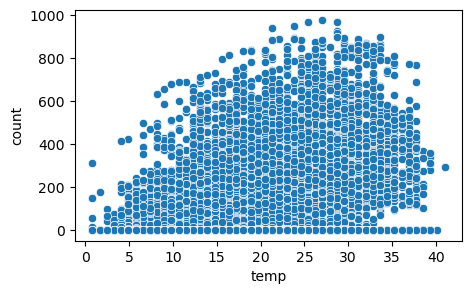

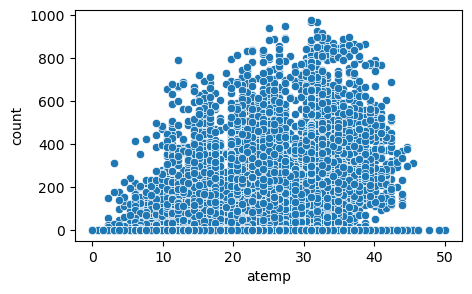

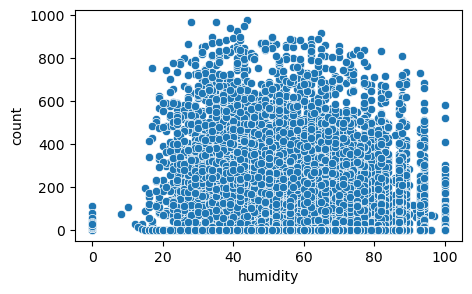

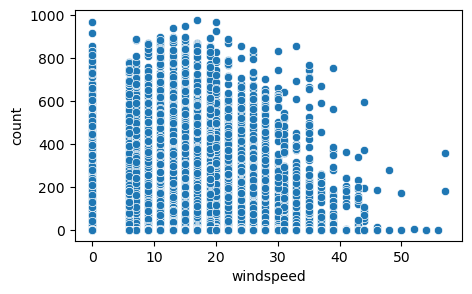

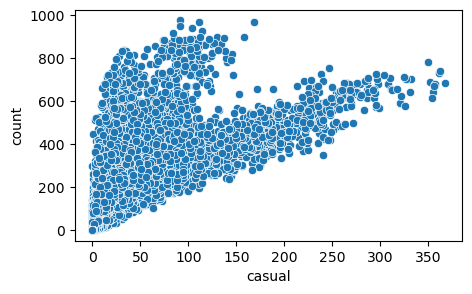

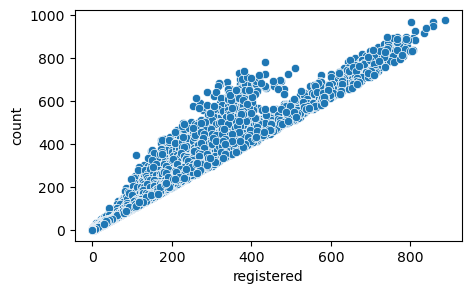

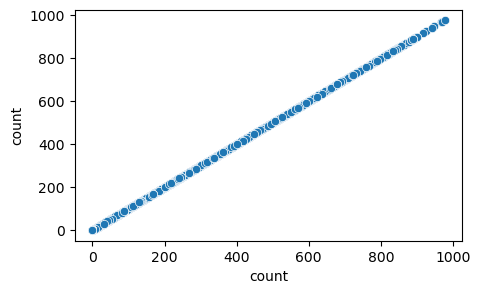

In [27]:
for feature in continuous_features:
    plt.figure(figsize=(5,3))
    sns.scatterplot(x=feature, y='count', data=train_test_data)
    plt.show()

- `casual` and `register` is highly correlated with count. [But we need to remember they are not present in the test data set]
- `temp` and `atemp` shows almost same nature and both has a good corr.
- `humidity` has a good corr.
- `windspeed` has lowest corr, we mightt drop it later. 

#### Time features

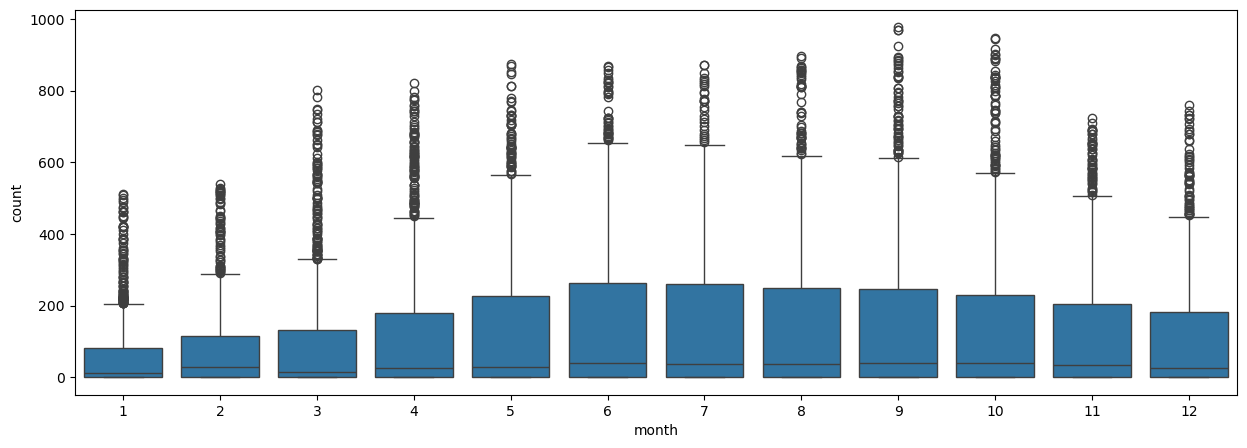

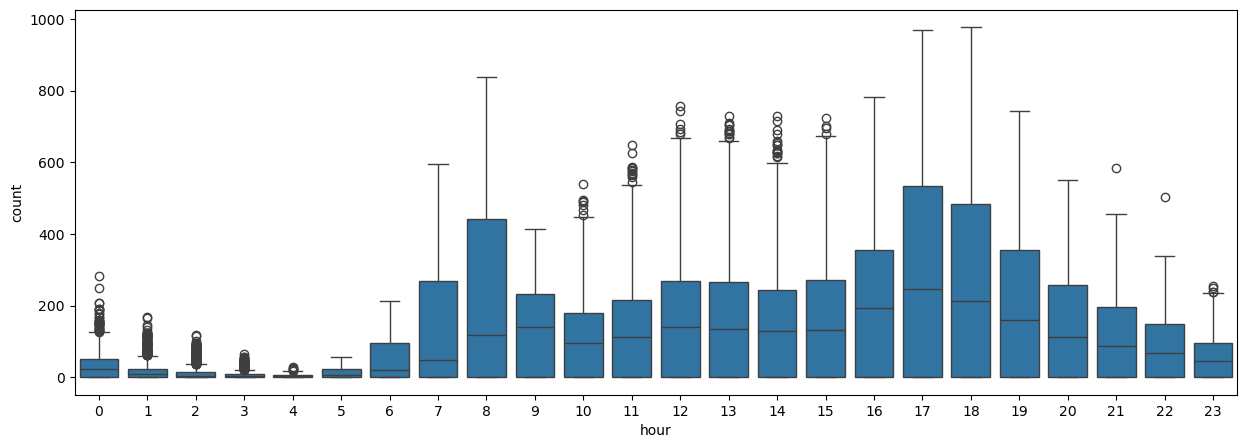

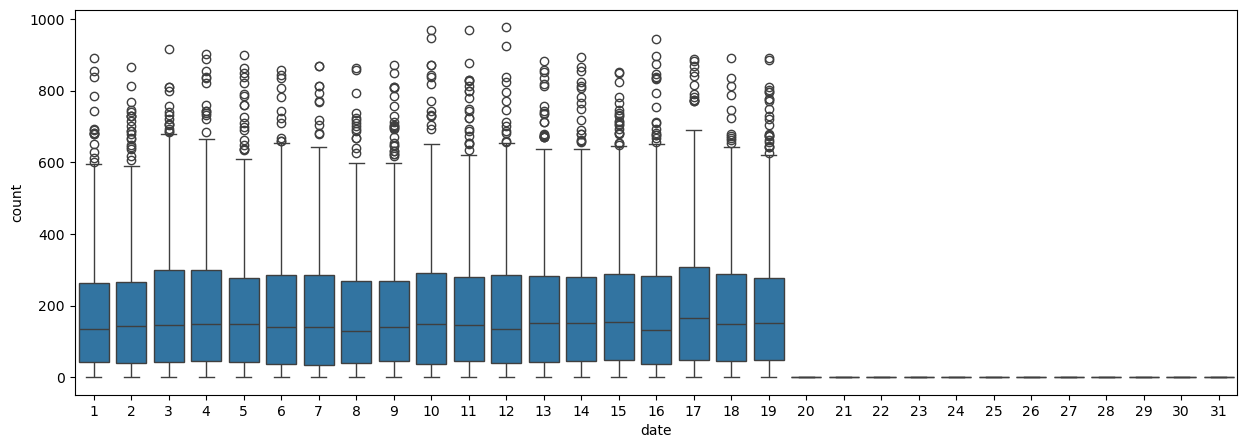

In [28]:
for feature in time_features:
    plt.figure(figsize=(15,5))
    sns.boxplot(x=feature, y='count', data=train_test_data)
    plt.show()
    

**Month**
- High : 6-10
- Average : 4-5, 11-12
- Low : 1-3
- This trend is kind of related to season


**Hour**
- High : 7-8, 16-19 [Morning and Evening]
- Average : 9-15, 20-21 [Noon and Night]
- Low : 0-6, 22-23 [Midnight and Early Morning]

**Date**
- The demand is almost same 

## 3.4 Multivariate Analysis (Time data) 

#### 3.4.1 Demand in different season and weather

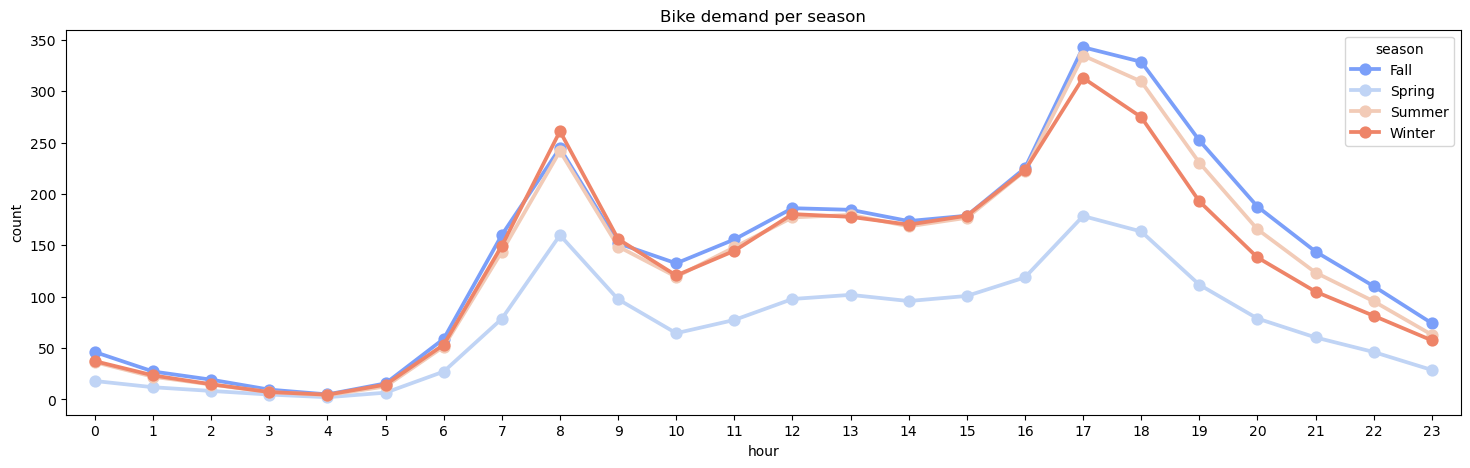

In [29]:
data = pd.DataFrame(train_test_data_mapped.groupby(['hour', 'season'], sort=True)['count'].mean()).reset_index()

plt.figure(figsize=(18, 5))
sns.pointplot(x=data["hour"], y=data["count"], hue=data["season"], palette='coolwarm')
plt.title('Bike demand per season')
plt.show()

- Fall season has highest demand.
- Spring has lowest.
- Summer and Winter have average.

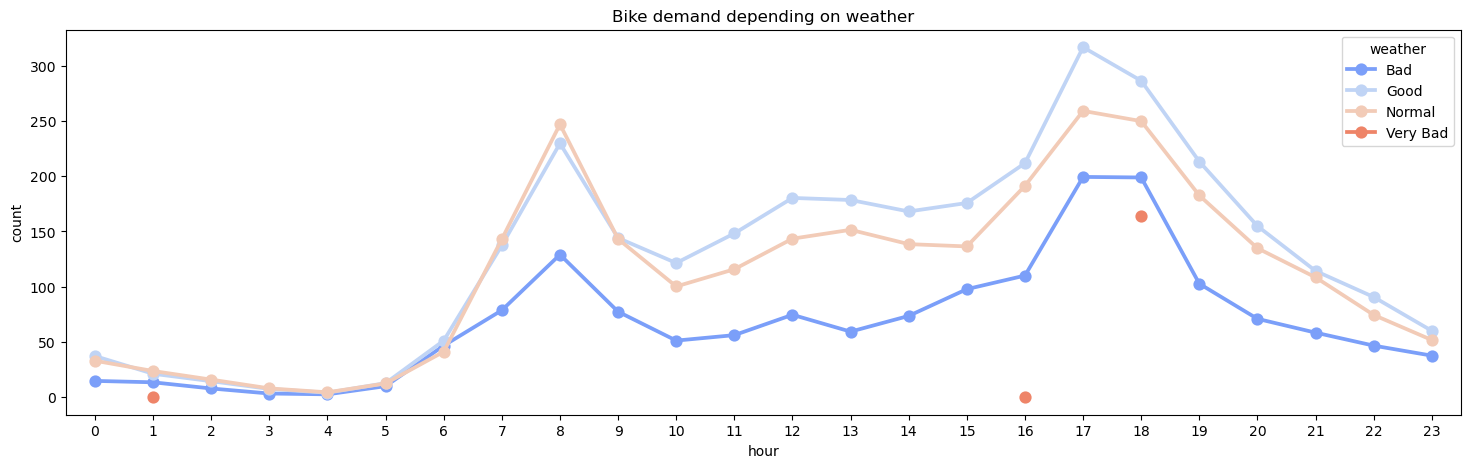

In [30]:
data = pd.DataFrame(train_test_data_mapped.groupby(['hour', 'weather'], sort=True)['count'].mean()).reset_index()

plt.figure(figsize=(18, 5))
sns.pointplot(x=data["hour"], y=data["count"], hue=data["weather"], palette='coolwarm')
plt.title('Bike demand depending on weather')
plt.show()

- Good weather has most demant
- Bad weather has low demand.
- Normal weather has average demand.
- Very bad weather has lowest.

### 3.4.2 Weather in various season

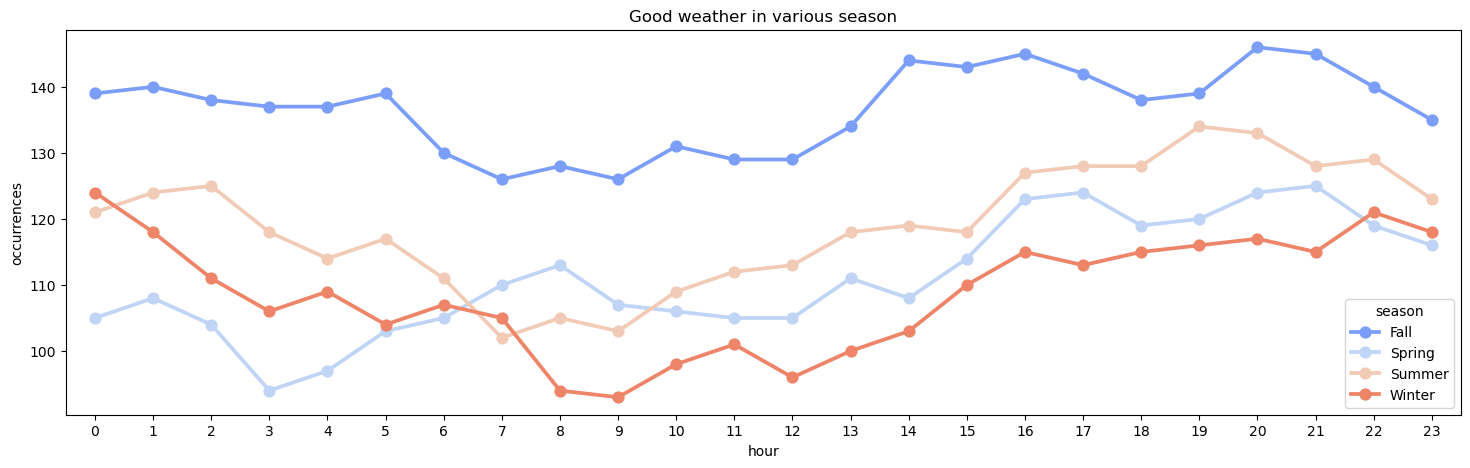

In [31]:
good_weather = train_test_data_mapped[train_test_data_mapped['weather'] == 'Good'][['hour', 'season']].copy()
data = pd.DataFrame({'occurrences' : good_weather.groupby(["hour","season"]).size()}).reset_index()


plt.figure(figsize=(18, 5))
sns.pointplot(x=data["hour"], y=data["occurrences"], hue=data["season"], palette='coolwarm')
plt.title('Good weather in various season')
plt.show()

- Fall season has often good wather.
- Winter season is unlikely to have good weather

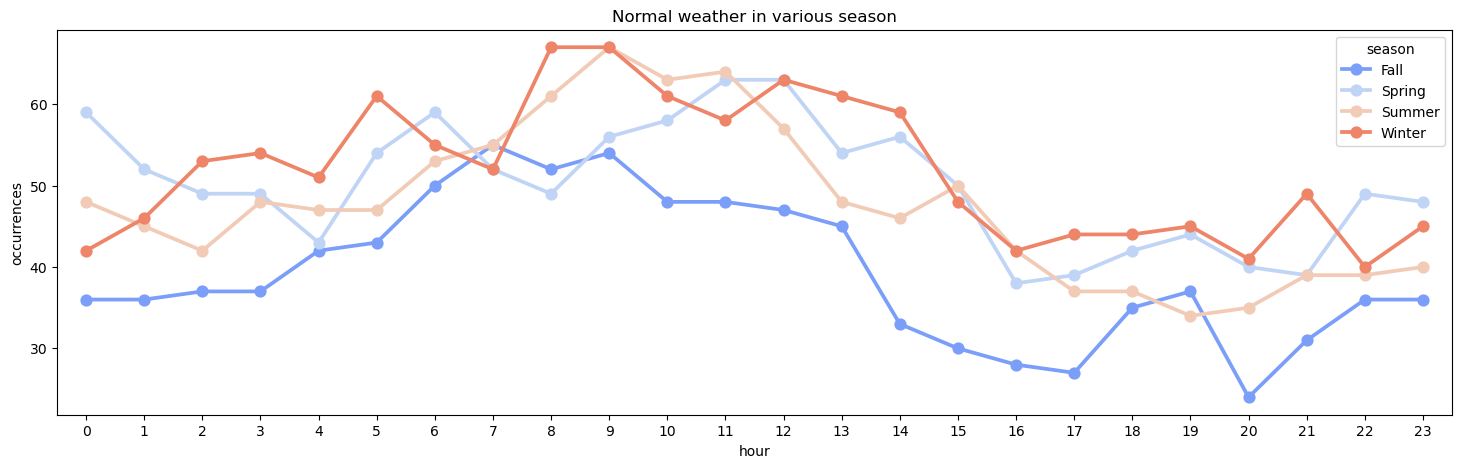

In [32]:
normal_weather = train_test_data_mapped[train_test_data_mapped['weather'] == 'Normal'][['hour', 'season']].copy()
data = pd.DataFrame({'occurrences' : normal_weather.groupby(["hour","season"]).size()}).reset_index()


plt.figure(figsize=(18, 5))
sns.pointplot(x=data["hour"], y=data["occurrences"], hue=data["season"], palette='coolwarm')
plt.title('Normal weather in various season')
plt.show()

- Except Fall season others have similar trend for normal wather.

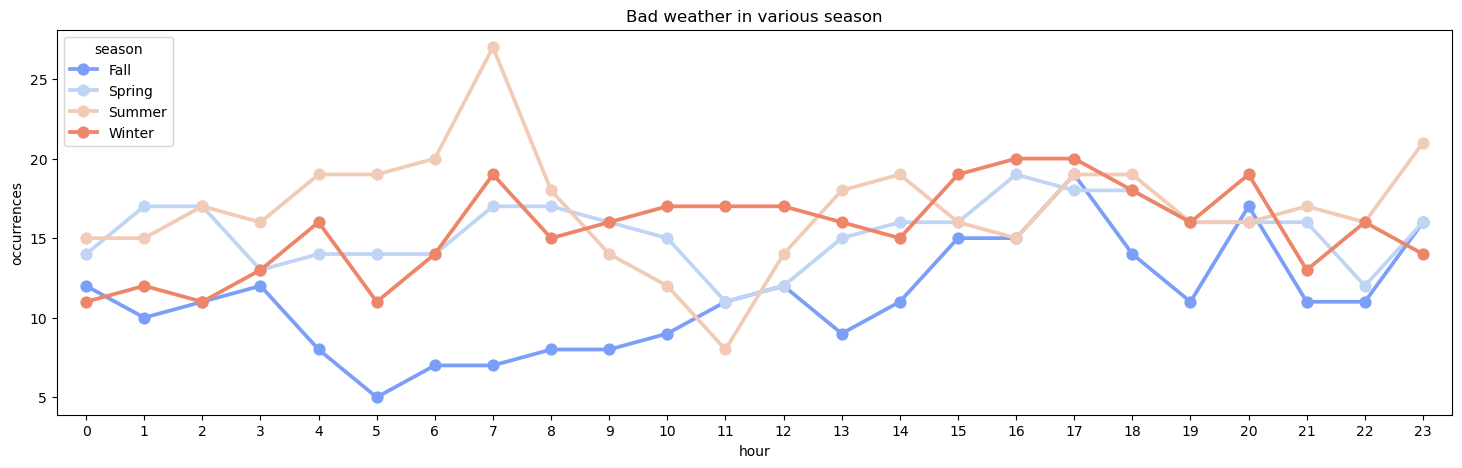

In [33]:
bad_weather = train_test_data_mapped[train_test_data_mapped['weather'] == 'Bad'][['hour', 'season']].copy()
data = pd.DataFrame({'occurrences' : bad_weather.groupby(["hour","season"]).size()}).reset_index()


plt.figure(figsize=(18, 5))
sns.pointplot(x=data["hour"], y=data["occurrences"], hue=data["season"], palette='coolwarm')
plt.title('Bad weather in various season')
plt.show()

- Bad weather is most frequent in summer

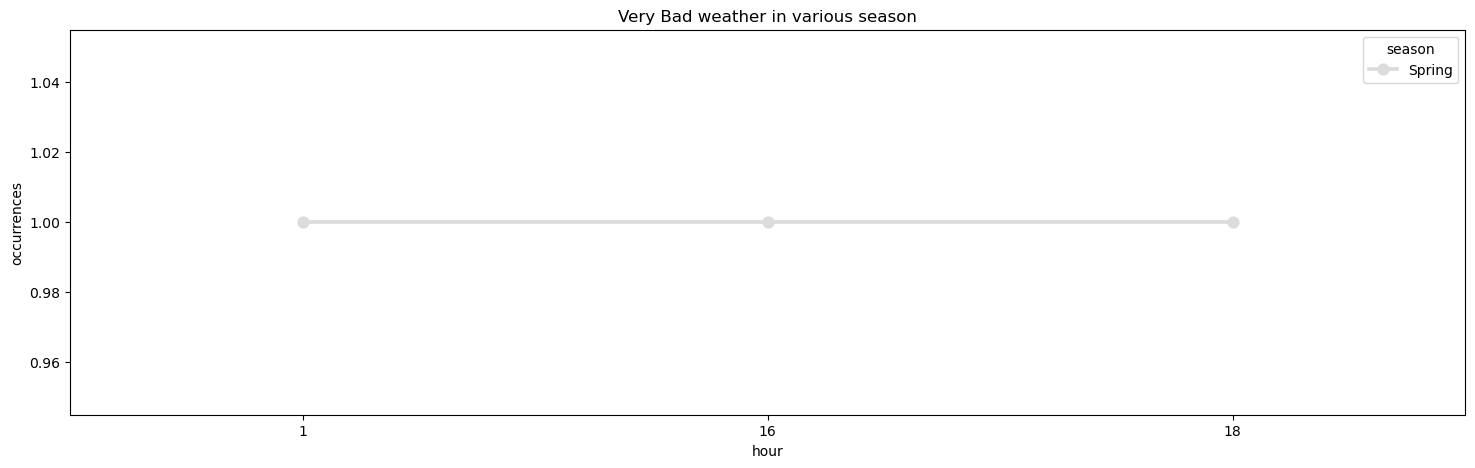

In [34]:
very_bad_weather = train_test_data_mapped[train_test_data_mapped['weather'] == 'Very Bad'][['hour', 'season']].copy()
data = pd.DataFrame({'occurrences' : very_bad_weather.groupby(["hour","season"]).size()}).reset_index()


plt.figure(figsize=(18, 5))
sns.pointplot(x=data["hour"], y=data["occurrences"], hue=data["season"], palette='coolwarm')
plt.title('Very Bad weather in various season')
plt.show()

- Very bad weather only occurs in summer